## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 1.0          # Natural frequency (rad/s)
w_p = 2*w_0      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
period = 2*jnp.pi/w_0
F_p = 0.03      # Amplitude of the w_p driving
Qual = 1000.0
GAMMA = w_0/(2*Qual)
gamma = .005          # Nonlinearity coefficient (Duffing term)

k_13 = .1
k_23 = .1

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .1             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 5000# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
y0 = jnp.zeros(6)



CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    x1, v1, x2, v2, x3, v3 = state
    dx1dt = v1
    dv1dt =  -w_0/Qual * v1 -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x1 - gamma * x1**3 - k_13 * (x1 - x3)
    dx2dt = v2
    dv2dt =  -w_0/Qual * v2 -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x2 - gamma * x2**3 - k_23 * (x2 - x3)
    dx3dt = v3
    dv3dt =  -w_0/Qual * v3 -  (w_0**2 -0*F_p/M * jnp.cos(w_p * t)) * x3 - k_13 * (x1 - x3) - k_23 * (x2 - x3)
    return jnp.array([dx1dt, dv1dt, dx2dt, dv2dt, dx3dt, dv3dt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    noise_strength =  jnp.sqrt(4*GAMMA*k_B * T/M)  
    noise_matrix = jnp.zeros((6, 6))
    noise_matrix = noise_matrix.at[1, 1].set(noise_strength)
    noise_matrix = noise_matrix.at[3, 3].set(noise_strength)
    noise_matrix = noise_matrix.at[5, 5].set(0.)
    return noise_matrix

In [4]:
w_shape = (6,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    # stepsize_controller=PIDController(rtol=rtol, atol=atol),
)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

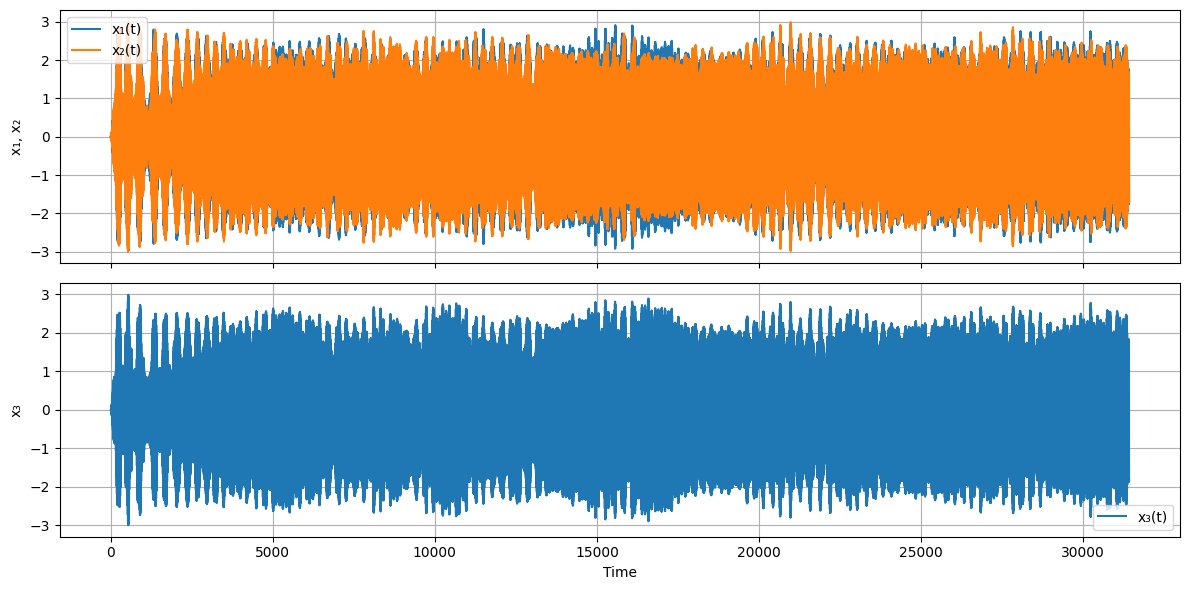

In [7]:
# Define start and end times as fractions of total time
start_frac = 0.0  # Start at beginning
end_frac = 1    # Show first 20%

# Calculate indices for the time window
start_idx = int(len(ts_dim) * start_frac)
end_idx = int(len(ts_dim) * end_frac)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot x1 and x2 on the same axes (within time window)
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 0], label='x₁(t)')
ax1.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 2], label='x₂(t)')
ax1.set_ylabel('x₁, x₂')
ax1.grid(True)
ax1.legend()

# Plot x3 (within time window)
ax2.plot(ts_dim[start_idx:end_idx], solution_x.ys[start_idx:end_idx, 4], label='x₃(t)')
ax2.set_xlabel('Time')
ax2.set_ylabel('x₃')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

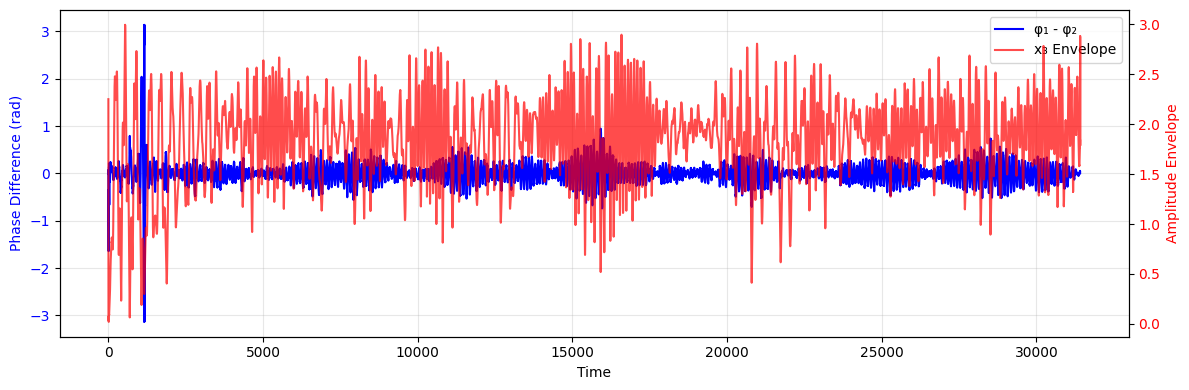

In [8]:

from scipy.signal import hilbert
import numpy as np

x1 = solution_x.ys[:, 0]
x2 = solution_x.ys[:, 2]
x3 = solution_x.ys[:, 4]

# Extract phases using Hilbert transform
analytic_signal_x1 = hilbert(x1)
analytic_signal_x2 = hilbert(x2)
analytic_signal_x3 = hilbert(x3)

# Calculate phase difference between x₁ and x₂
phase_diff = np.angle(analytic_signal_x1) - np.angle(analytic_signal_x2)
# Wrap to [-π, π]
phase_diff = np.mod(phase_diff + np.pi, 2 * np.pi) - np.pi

# Calculate envelope of x₃
envelope = np.abs(analytic_signal_x3)

# Create figure with single plot and two y-axes
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

# Plot phase difference on left y-axis
l1 = ax1.plot(ts_dim[start_idx:end_idx], 
              phase_diff[start_idx:end_idx], 
              label='φ₁ - φ₂', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Phase Difference (rad)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot envelope on right y-axis
l2 = ax2.plot(ts_dim[start_idx:end_idx], 
              envelope[start_idx:end_idx],
              label='x₃ Envelope', color='red', alpha=0.7)
ax2.set_ylabel('Amplitude Envelope', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()